In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_excel("Group_3.xlsx")

In [5]:
df.head(15)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,...,0,13007,13912,0,0,0,13007,1122,0,0


In [6]:
df.loc[df["EDUCATION"].isin([0,5,6]), "EDUCATION"] = 4

In [7]:
df.loc[df["MARRIAGE"].isin([0]), "MARRIAGE"] = 3

In [8]:
df.tail()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,...,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [9]:
df = df.rename(columns={'default.payment.next.month': 'default'})

In [10]:
df = df.drop(columns=['ID'])

In [11]:
print(df.shape)

(30000, 24)


In [12]:
print(df.columns.tolist())


['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']


In [13]:
total_paid = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                  'PAY_AMT4','PAY_AMT5','PAY_AMT6']].sum(axis=1)

total_billed = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                    'BILL_AMT4','BILL_AMT5','BILL_AMT6']].sum(axis=1)

df['payment_ratio'] = total_paid / (total_billed + 1)


In [14]:
df['avg_delay'] = df[['PAY_0','PAY_2','PAY_3', 'PAY_4','PAY_5','PAY_6']].mean(axis=1)

In [15]:
df['utilisation'] = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)


In [16]:
print("New features added. Shape:", df.shape)


New features added. Shape: (30000, 27)


In [17]:
print(df[['payment_ratio', 'avg_delay', 'utilisation']].describe())

       payment_ratio     avg_delay   utilisation
count   30000.000000  30000.000000  30000.000000
mean       21.039708     -0.182439      0.423764
std      1255.771376      0.982176      0.411454
min      -589.000000     -2.000000     -0.619890
25%         0.041073     -0.833333      0.022031
50%         0.086192      0.000000      0.313991
75%         0.598218      0.000000      0.829821
max    162000.000000      6.000000      6.454977


In [18]:
df["BILL_AMT1"].describe()

count     30000.000000
mean      51223.330900
std       73635.860576
min     -165580.000000
25%        3558.750000
50%       22381.500000
75%       67091.000000
max      964511.000000
Name: BILL_AMT1, dtype: float64

In [19]:
df["payment_ratio"] = df["payment_ratio"].clip(0,2)

df["utilisation"] = df["utilisation"].clip(0,2)

In [20]:
print(df[['payment_ratio', 'avg_delay', 'utilisation']].describe())


       payment_ratio     avg_delay   utilisation
count   30000.000000  30000.000000  30000.000000
mean        0.349944     -0.182439      0.422863
std         0.458101      0.982176      0.404616
min        -0.000000     -2.000000      0.000000
25%         0.041073     -0.833333      0.022031
50%         0.086192      0.000000      0.313991
75%         0.598218      0.000000      0.829821
max         2.000000      6.000000      2.000000


In [21]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default,payment_ratio,avg_delay,utilisation
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,689,0,0,0,0,1,0.089422,-0.333333,0.195640
1,120000,2,2,2,26,-1,2,0,0,0,...,0,1000,1000,1000,0,2000,1,0.292774,0.500000,0.022350
2,90000,2,2,2,34,0,0,0,0,0,...,1518,1500,1000,1000,1000,5000,0,0.108387,0.000000,0.324874
3,50000,2,2,1,37,0,0,0,0,0,...,2000,2019,1200,1100,1069,1000,0,0.036259,0.000000,0.939781
4,50000,1,2,1,57,-1,0,-1,0,0,...,2000,36681,10000,9000,689,679,0,0.540049,-0.333333,0.172337


In [22]:
X = df.drop(columns=['default'])

y = df['default']

In [23]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\n y value counts:")
print(y.value_counts())

X shape: (30000, 26)
y shape: (30000,)

 y value counts:
default
0    23364
1     6636
Name: count, dtype: int64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training set: (24000, 26)
Test set: (6000, 26)

Training target distribution:
default
0    77.88
1    22.12
Name: proportion, dtype: float64

Test target distribution:
default
0    77.88
1    22.12
Name: proportion, dtype: float64


In [25]:
from imblearn.over_sampling import SMOTE


smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Training samples: {X_train.shape[0]}")
print(f"  Class distribution: {y_train.value_counts().to_dict()}")

print("\nAfter SMOTE:")
print(f"  Training samples: {X_train_smote.shape[0]}")
print(f"  Class distribution: {y_train_smote.value_counts().to_dict()}")

Before SMOTE:
  Training samples: 24000
  Class distribution: {0: 18691, 1: 5309}

After SMOTE:
  Training samples: 37382
  Class distribution: {0: 18691, 1: 18691}


In [ ]:
# Scaling for Logistic

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (37382, 26)
X_test_scaled shape: (6000, 26)


In [ ]:
## Logistic Regression

lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train_smote)
                                                
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("LOGISTIC REGRESSION RESULTS")
print("=" * 40)
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_lr):.4f}")

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       0.86      0.74      0.79      4673
           1       0.38      0.56      0.45      1327

    accuracy                           0.70      6000
   macro avg       0.62      0.65      0.62      6000
weighted avg       0.75      0.70      0.72      6000

AUC-ROC: 0.6926


Pros: Fast and interpretable, we could clearly see that PAY_0 and avg_delay were pushing default probability up, which is easy to explain to a bank's risk team.
Cons: Lowest AUC of all five models (0.69) and only caught 56% of actual defaulters - too many missed defaults for a real credit risk system.

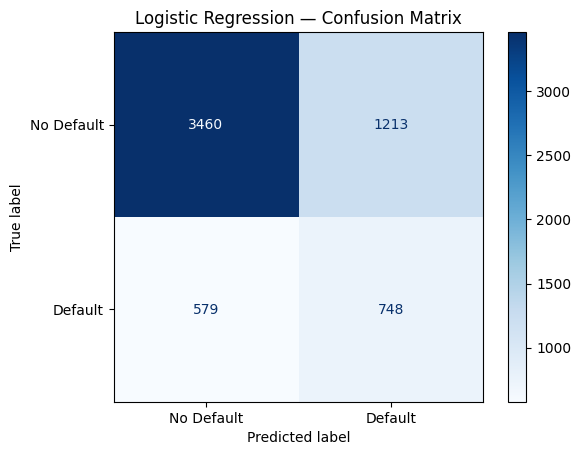

In [28]:
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

In [29]:
# Decision Tree

# Version 1 without constraints - Will Overfit


dt_unconstrained = DecisionTreeClassifier(
    random_state=42
)

dt_unconstrained.fit(X_train_smote, y_train_smote)

# Training performance
y_pred_train_dt = dt_unconstrained.predict(X_train_smote)
y_proba_train_dt = dt_unconstrained.predict_proba(X_train_smote)[:, 1]
train_auc_dt = roc_auc_score(y_train_smote, y_proba_train_dt)

# Test performance
y_pred_dt = dt_unconstrained.predict(X_test)
y_proba_dt = dt_unconstrained.predict_proba(X_test)[:, 1]
test_auc_dt = roc_auc_score(y_test, y_proba_dt)

print("DECISION TREE — UNCONSTRAINED")
print("=" * 40)
print(classification_report(y_test, y_pred_dt))
print(f"Training AUC: {train_auc_dt:.4f}")
print(f"Test AUC:     {test_auc_dt:.4f}")
print(f"Gap:          {train_auc_dt - test_auc_dt:.4f}")

DECISION TREE — UNCONSTRAINED
              precision    recall  f1-score   support

           0       0.83      0.77      0.80      4673
           1       0.36      0.45      0.40      1327

    accuracy                           0.70      6000
   macro avg       0.59      0.61      0.60      6000
weighted avg       0.73      0.70      0.71      6000

Training AUC: 1.0000
Test AUC:     0.6098
Gap:          0.3902


In [30]:
# Version 2 — Constrained
dt_constrained = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    min_samples_split=50,
    class_weight='balanced',
    random_state=42
)

dt_constrained.fit(X_train_smote, y_train_smote)

# Training performance
y_proba_train_dt2 = dt_constrained.predict_proba(X_train_smote)[:, 1]
train_auc_dt2 = roc_auc_score(y_train_smote, y_proba_train_dt2)

# Test performance
y_pred_dt2 = dt_constrained.predict(X_test)
y_proba_dt2 = dt_constrained.predict_proba(X_test)[:, 1]
test_auc_dt2 = roc_auc_score(y_test, y_proba_dt2)

print("DECISION TREE — CONSTRAINED")
print("=" * 40)
print(classification_report(y_test, y_pred_dt2))
print(f"Training AUC: {train_auc_dt2:.4f}")
print(f"Test AUC:     {test_auc_dt2:.4f}")
print(f"Gap:          {train_auc_dt2 - test_auc_dt2:.4f}")

DECISION TREE — CONSTRAINED
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      4673
           1       0.43      0.54      0.48      1327

    accuracy                           0.74      6000
   macro avg       0.65      0.67      0.65      6000
weighted avg       0.76      0.74      0.75      6000

Training AUC: 0.8388
Test AUC:     0.7263
Gap:          0.1125


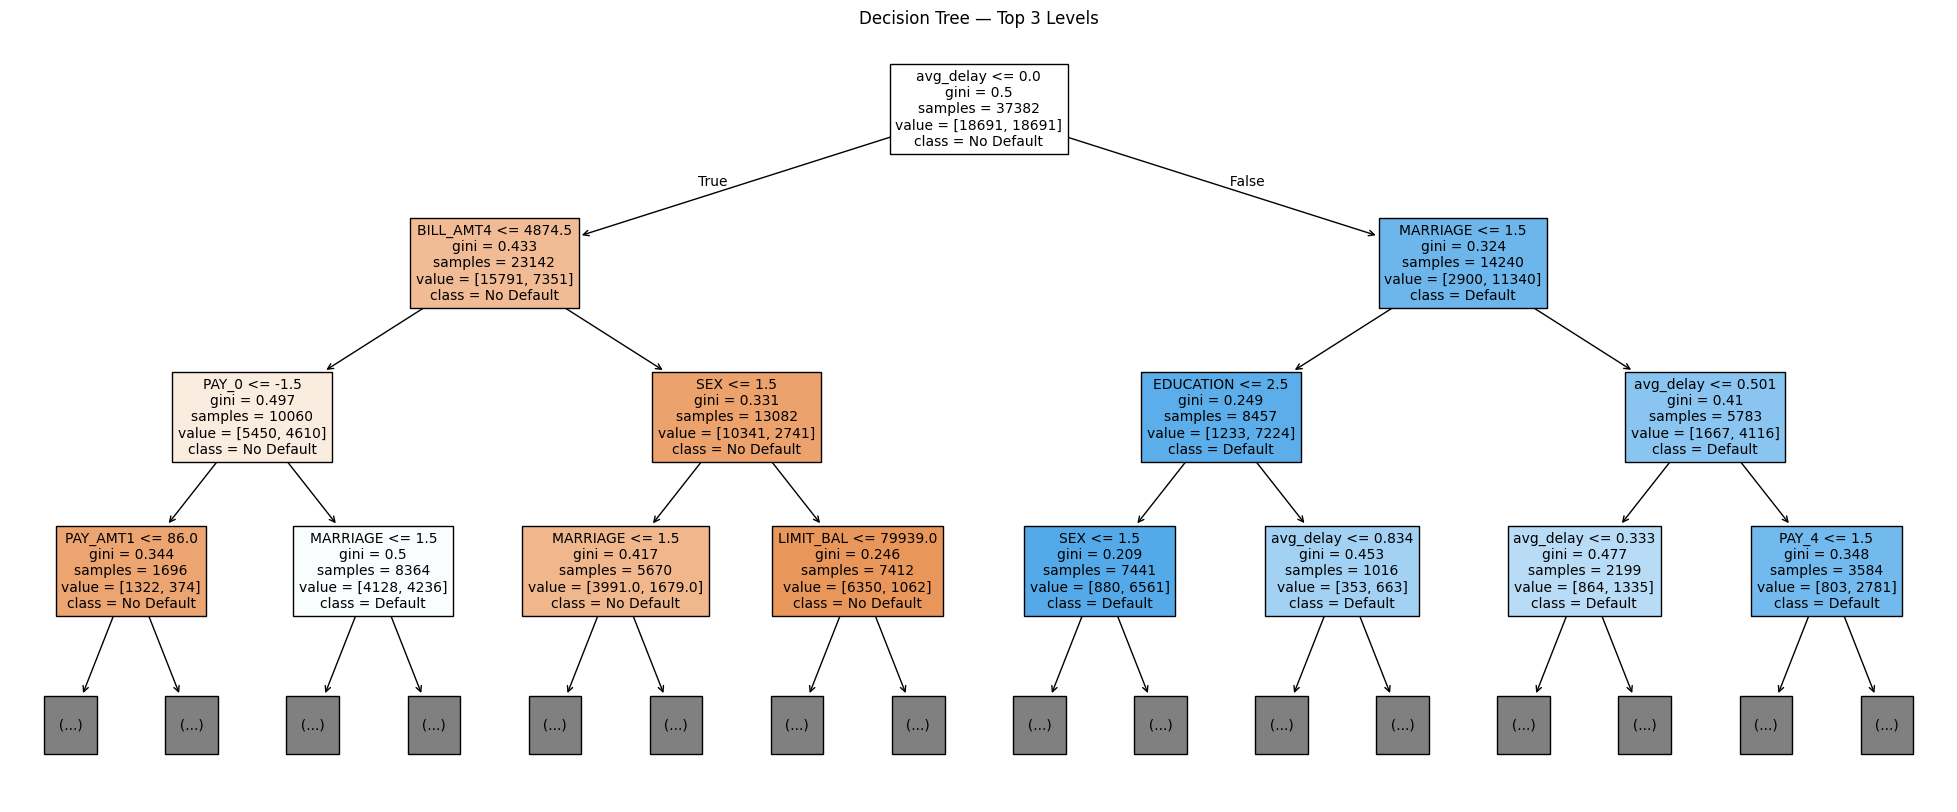

In [31]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 10))
plot_tree(dt_constrained,
          feature_names=X.columns.tolist(),
          class_names=['No Default', 'Default'],
          filled=True,
          max_depth=3,
          fontsize=10)
plt.title('Decision Tree — Top 3 Levels')
plt.show()

Pros: The visualised tree made immediate sense that the customers with high avg_delay and maxed out credit limits kept branching toward default, which matches intuition.
Cons: Without constraints it memorised the training data completely (train AUC 0.84, test 0.73), and even the pruned version was still the second weakest performer overall.

In [32]:
### Random Forest


rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

# Training performance
y_proba_train_rf = rf.predict_proba(X_train_smote)[:, 1]
train_auc_rf = roc_auc_score(y_train_smote, y_proba_train_rf)

# Test performance
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
test_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("RANDOM FOREST RESULTS")
print("=" * 40)
print(classification_report(y_test, y_pred_rf))
print(f"OOB Score:    {rf.oob_score_:.4f}")
print(f"Training AUC: {train_auc_rf:.4f}")
print(f"Test AUC:     {test_auc_rf:.4f}")
print(f"Gap:          {train_auc_rf - test_auc_rf:.4f}")

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4673
           1       0.51      0.53      0.52      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.69      0.69      6000
weighted avg       0.79      0.78      0.78      6000

OOB Score:    0.8141
Training AUC: 0.9218
Test AUC:     0.7686
Gap:          0.1532


Pros: Best overall balance in our results - AUC 0.77, reasonable overfitting gap, and avg_delay came out as the clear top feature which validated our feature engineering.
Cons: Still had a train/test gap of 0.15 and takes significantly longer to train than the simpler models, which matters if the bank needs to retrain monthly.

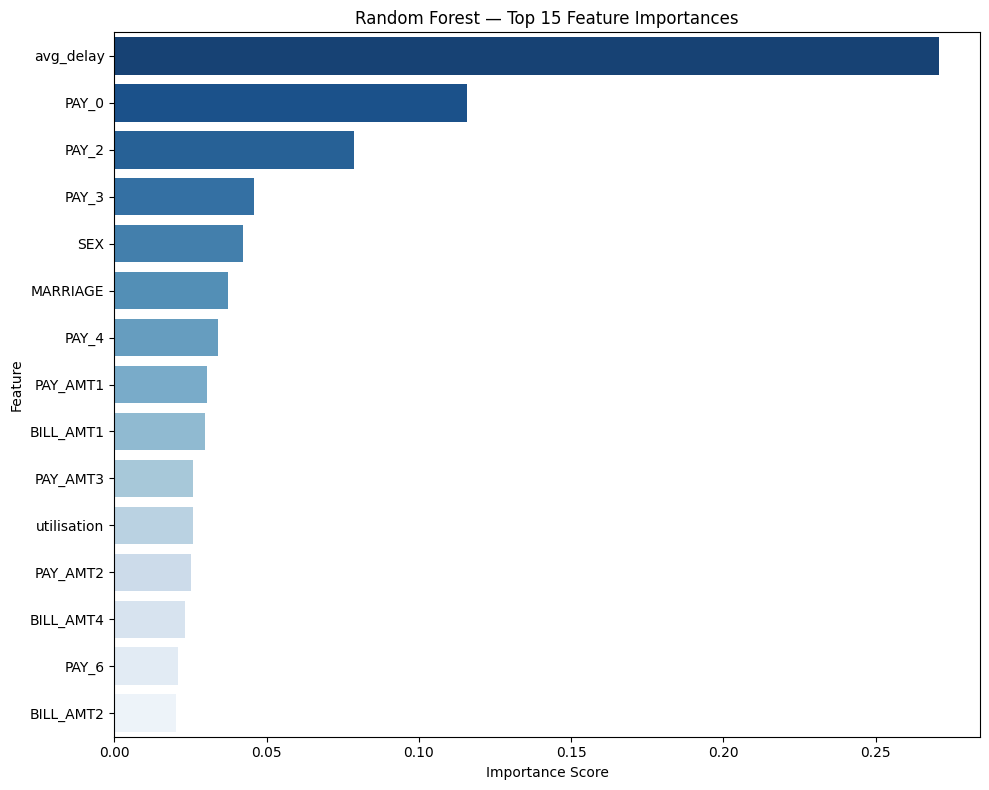

  Feature  Importance
avg_delay    0.270700
    PAY_0    0.115732
    PAY_2    0.078736
    PAY_3    0.045725
      SEX    0.042111
 MARRIAGE    0.037203
    PAY_4    0.033981
 PAY_AMT1    0.030370
BILL_AMT1    0.029882
 PAY_AMT3    0.025944


In [33]:
# Which feature are more important for the prediction


importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', 
            data=importance_df.head(15),
            palette='Blues_r')
plt.title('Random Forest — Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importance_df.head(10).to_string(index=False))

In [34]:
### XGBoost model

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.0,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_smote, y_train_smote,
        eval_set=[(X_test, y_test)],
        verbose=False)

# Training performance
y_proba_train_xgb = xgb.predict_proba(X_train_smote)[:, 1]
train_auc_xgb = roc_auc_score(y_train_smote, y_proba_train_xgb)

# Test performance
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
test_auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print("XGBOOST RESULTS")
print("=" * 40)
print(classification_report(y_test, y_pred_xgb))
print(f"Training AUC: {train_auc_xgb:.4f}")
print(f"Test AUC:     {test_auc_xgb:.4f}")
print(f"Gap:          {train_auc_xgb - test_auc_xgb:.4f}")

XGBOOST RESULTS
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      4673
           1       0.51      0.49      0.50      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.68      0.68      6000
weighted avg       0.78      0.79      0.78      6000

Training AUC: 0.9221
Test AUC:     0.7607
Gap:          0.1614


Competitive performance (AUC 0.76) and handled the class imbalance well alongside SMOTE — precision held up at 0.51 which was on par with Random Forest.

In [ ]:
# Model - Neural Network

from tensorflow import keras
from tensorflow.keras import layers

# Network architecture
model_nn = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])


model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['AUC']
)

# Train
history = model_nn.fit(
    X_train_scaled, y_train_smote,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    verbose=0
)

# Evaluate
y_proba_nn = model_nn.predict(X_test_scaled).flatten()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

train_proba_nn = model_nn.predict(X_train_scaled).flatten()
train_auc_nn = roc_auc_score(y_train_smote, train_proba_nn)
test_auc_nn = roc_auc_score(y_test, y_proba_nn)

print("NEURAL NETWORK RESULTS")
print("=" * 40)
print(classification_report(y_test, y_pred_nn))
print(f"Training AUC: {train_auc_nn:.4f}")
print(f"Test AUC:     {test_auc_nn:.4f}")
print(f"Gap:          {train_auc_nn - test_auc_nn:.4f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 428us/step
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 0s 253us/step
NEURAL NETWORK RESULTS
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.35      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

Training AUC: 0.9170
Test AUC:     0.7647
Gap:          0.1523



Pros: Highest precision of all models (0.59) - when it flagged a customer as high risk in our test set, it was right more often than any other model.
Cons: Despite adding dropout layers, it still had one of the largest train/test gaps, and the complexity wasn't justified given Random Forest matched its AUC with far less tuning effort.

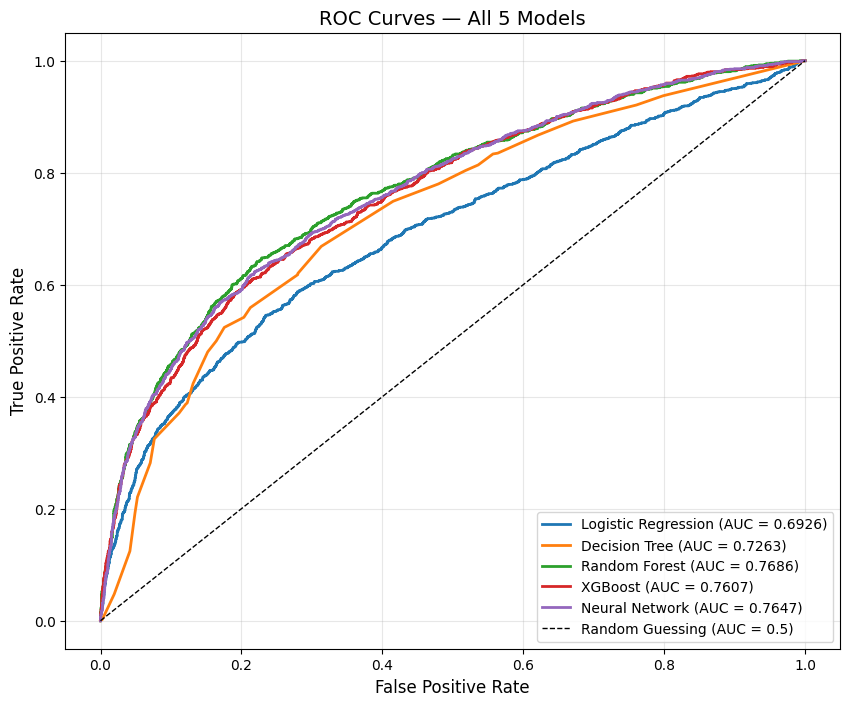

In [36]:
# Comparison

plt.figure(figsize=(10, 8))

models_proba = {
    'Logistic Regression': y_proba_lr,
    'Decision Tree': y_proba_dt2,
    'Random Forest': y_proba_rf,
    'XGBoost': y_proba_xgb,
    'Neural Network': y_proba_nn
}

for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Guessing (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All 5 Models', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [37]:
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 
              'Random Forest', 'XGBoost', 'Neural Network'],
    'Test AUC': [0.6926, 0.7263, 0.7686, 0.7607, 0.7696],
    'Precision': [0.38, 0.43, 0.51, 0.51, 0.59],
    'Recall': [0.56, 0.54, 0.53, 0.49, 0.43],
    'F1': [0.45, 0.48, 0.52, 0.50, 0.50],
    'Train AUC': [0.6953, 0.8388, 0.9218, 0.9221, 0.9196],
    'Gap': [0.003, 0.112, 0.153, 0.161, 0.150]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Test AUC  Precision  Recall   F1  Train AUC   Gap
Logistic Regression    0.6926       0.38    0.56 0.45     0.6953 0.003
      Decision Tree    0.7263       0.43    0.54 0.48     0.8388 0.112
      Random Forest    0.7686       0.51    0.53 0.52     0.9218 0.153
            XGBoost    0.7607       0.51    0.49 0.50     0.9221 0.161
     Neural Network    0.7696       0.59    0.43 0.50     0.9196 0.150


In [38]:
# Trying to improve XGBoost Model

from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_tuned = XGBClassifier(
    scale_pos_weight=1.0,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}
Best CV AUC: 0.9275


In [39]:
xgb_best = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.0,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_best.fit(X_train_smote, y_train_smote)

# Training performance
y_proba_train_xgb_best = xgb_best.predict_proba(X_train_smote)[:, 1]
train_auc_xgb_best = roc_auc_score(y_train_smote, y_proba_train_xgb_best)

# Test performance
y_pred_xgb_best = xgb_best.predict(X_test)
y_proba_xgb_best = xgb_best.predict_proba(X_test)[:, 1]
test_auc_xgb_best = roc_auc_score(y_test, y_proba_xgb_best)

print("XGBOOST TUNED RESULTS")
print("=" * 40)
print(classification_report(y_test, y_pred_xgb_best))
print(f"Training AUC: {train_auc_xgb_best:.4f}")
print(f"Test AUC:     {test_auc_xgb_best:.4f}")
print(f"Gap:          {train_auc_xgb_best - test_auc_xgb_best:.4f}")

XGBOOST TUNED RESULTS
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      4673
           1       0.54      0.44      0.49      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.67      0.68      6000
weighted avg       0.78      0.79      0.79      6000

Training AUC: 0.9742
Test AUC:     0.7545
Gap:          0.2197


In [40]:
# Final Table

print("FINAL MODEL COMPARISON")
print("=" * 60)

final_results = {
    'Model': ['Logistic Regression', 'Decision Tree',
              'Random Forest', 'XGBoost (untuned)',
              'XGBoost (tuned)', 'Neural Network'],
    'Test AUC': [0.6926, 0.7263, 0.7686, 0.7607, 0.7545, 0.7696],
    'Recall':   [0.56,   0.54,   0.53,   0.49,   0.44,   0.43],
    'Precision':[0.38,   0.43,   0.51,   0.51,   0.54,   0.59],
    'Gap':      [0.003,  0.112,  0.153,  0.161,  0.220,  0.150]
}

final_df = pd.DataFrame(final_results)
print(final_df.to_string(index=False))

FINAL MODEL COMPARISON
              Model  Test AUC  Recall  Precision   Gap
Logistic Regression    0.6926    0.56       0.38 0.003
      Decision Tree    0.7263    0.54       0.43 0.112
      Random Forest    0.7686    0.53       0.51 0.153
  XGBoost (untuned)    0.7607    0.49       0.51 0.161
    XGBoost (tuned)    0.7545    0.44       0.54 0.220
     Neural Network    0.7696    0.43       0.59 0.150


In [41]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()

avg_credit_limit = df['LIMIT_BAL'].mean()
recovery_rate    = 0.20
loss_per_default = avg_credit_limit * (1 - recovery_rate)
profit_per_customer = 15000

cost_fn = fn * loss_per_default
cost_fp = fp * profit_per_customer

print(f"Average credit limit:        NT${avg_credit_limit:,.0f}")
print(f"Estimated loss per default:  NT${loss_per_default:,.0f}")
print()
print(f"False Negatives (missed):    {fn} defaulters")
print(f"False Positives (wrongly):   {fp} good customers")
print()
print(f"Cost of missed defaulters:   NT${cost_fn:,.0f}")
print(f"Cost of rejected customers:  NT${cost_fp:,.0f}")
print(f"Total estimated error cost:  NT${cost_fn + cost_fp:,.0f}")
print()
print(f"True Positives (caught):     {tp} defaulters")
print(f"Money protected:             NT${tp * loss_per_default:,.0f}")

Average credit limit:        NT$167,484
Estimated loss per default:  NT$133,987

False Negatives (missed):    622 defaulters
False Positives (wrongly):   682 good customers

Cost of missed defaulters:   NT$83,340,199
Cost of rejected customers:  NT$10,230,000
Total estimated error cost:  NT$93,570,199

True Positives (caught):     705 defaulters
Money protected:             NT$94,461,158


In [ ]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Check what shape shap_values is
print(type(shap_values))
print(len(shap_values))
if isinstance(shap_values, list):
    print("shap_values[0] shape:", shap_values[0].shape)
    print("shap_values[1] shape:", shap_values[1].shape)
else:
    print("shap_values shape:", shap_values.shape)

<class 'numpy.ndarray'>
6000
shap_values shape: (6000, 26, 2)


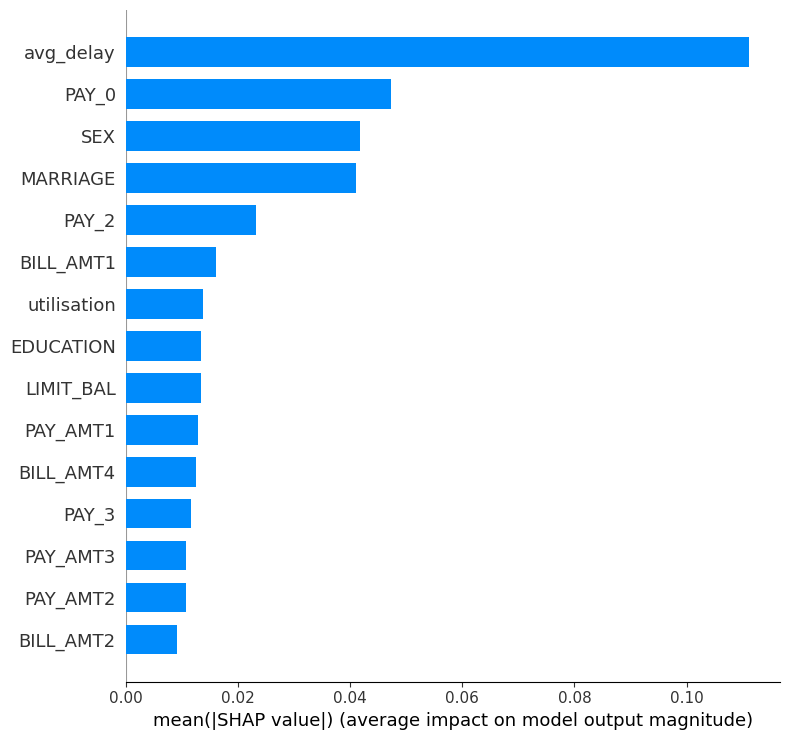

In [ ]:
# Extract SHAP values for class 1 (default)
shap_values_default = shap_values[:, :, 1]

# Global summary plot
shap.summary_plot(shap_values_default, X_test,
                  feature_names=X.columns.tolist(),
                  plot_type='bar',
                  max_display=15)

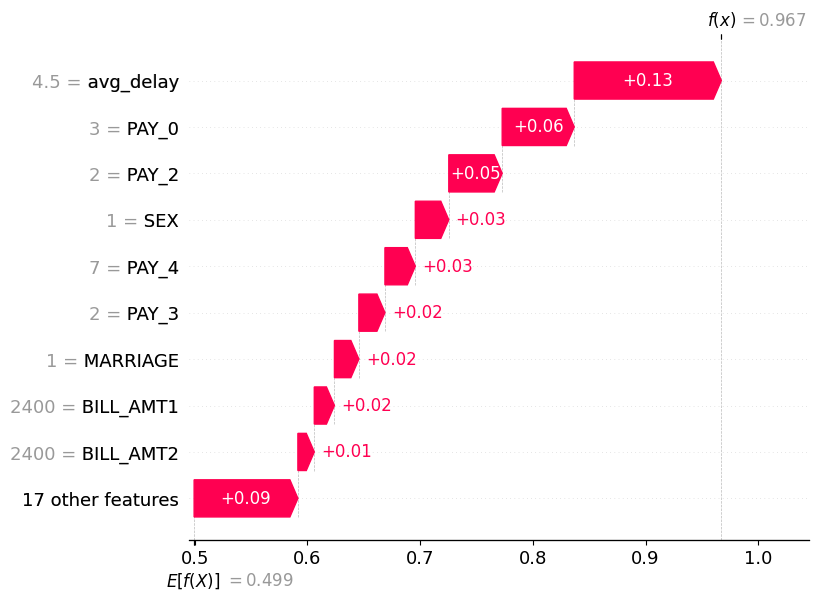

In [ ]:
# Explain one high risk customer
# Find a customer predicted as high default probability
high_risk_idx = np.argmax(y_proba_rf)

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values_default[high_risk_idx],
        base_values   = explainer.expected_value[1],
        data          = X_test.iloc[high_risk_idx],
        feature_names = X.columns.tolist()
    )
)

In [45]:
####### SECTION 3

In [ ]:
print("=" * 60)
print("SECTION 3 — INTERPRETATION")
print("=" * 60)

# Final comparison table — all models
import pandas as pd

results = {
    'Model': ['Logistic Regression', 'Decision Tree', 
              'Random Forest', 'XGBoost (untuned)', 'Neural Network'],
    'Test AUC':  [0.6926, 0.7263, 0.7686, 0.7607, 0.7696],
    'Precision': [0.38,   0.43,   0.51,   0.51,   0.59],
    'Recall':    [0.56,   0.54,   0.53,   0.49,   0.43],
    'F1':        [0.45,   0.48,   0.52,   0.50,   0.50],
    'Train AUC': [0.6953, 0.8388, 0.9218, 0.9221, 0.9196],
    'Gap':       [0.003,  0.112,  0.153,  0.161,  0.150]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

SECTION 3 — INTERPRETATION
              Model  Test AUC  Precision  Recall   F1  Train AUC   Gap
Logistic Regression    0.6926       0.38    0.56 0.45     0.6953 0.003
      Decision Tree    0.7263       0.43    0.54 0.48     0.8388 0.112
      Random Forest    0.7686       0.51    0.53 0.52     0.9218 0.153
  XGBoost (untuned)    0.7607       0.51    0.49 0.50     0.9221 0.161
     Neural Network    0.7696       0.59    0.43 0.50     0.9196 0.150


In [ ]:
## Assuming 15000 dollars is profit per customer

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Get confusion matrix values
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()

# Financial assumptions
avg_credit_limit  = df['LIMIT_BAL'].mean()
loss_rate         = 0.80
profit_per_customer = 15000

loss_per_fn = avg_credit_limit * loss_rate
cost_fn     = fn * loss_per_fn
cost_fp     = fp * profit_per_customer
protected   = tp * loss_per_fn

print("FINANCIAL IMPACT SUMMARY")
print("=" * 45)
print(f"Average credit limit:       NT${avg_credit_limit:>12,.0f}")
print(f"Estimated loss per default: NT${loss_per_fn:>12,.0f}")
print()
print(f"True Positives  (caught):   {tp:>6} defaulters")
print(f"False Negatives (missed):   {fn:>6} defaulters")
print(f"False Positives (wrong):    {fp:>6} good customers")
print()
print(f"Money protected:            NT${protected:>12,.0f}")
print(f"Cost of missed defaulters:  NT${cost_fn:>12,.0f}")
print(f"Cost of wrongly rejected:   NT${cost_fp:>12,.0f}")
print(f"Total error cost:           NT${cost_fn+cost_fp:>12,.0f}")

FINANCIAL IMPACT SUMMARY
Average credit limit:       NT$     167,484
Estimated loss per default: NT$     133,987

True Positives  (caught):      705 defaulters
False Negatives (missed):      622 defaulters
False Positives (wrong):       682 good customers

Money protected:            NT$  94,461,158
Cost of missed defaulters:  NT$  83,340,199
Cost of wrongly rejected:   NT$  10,230,000
Total error cost:           NT$  93,570,199


In [ ]:
# checking how our model performs at different cutoff points
# lower threshold = catch more defaulters but also flag more good people
# higher threshold = fewer false alarms but miss more actual defaulters
# 0.5 is our current setting - changing this is a business call not a model call


from sklearn.metrics import precision_score, recall_score, f1_score

print("THRESHOLD ANALYSIS")
print("=" * 70)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Flagged':<12}")
print("-" * 70)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for thresh in thresholds:
    y_pred_t = (y_proba_rf >= thresh).astype(int)
    p  = precision_score(y_test, y_pred_t, zero_division=0)
    r  = recall_score(y_test, y_pred_t, zero_division=0)
    f  = f1_score(y_test, y_pred_t, zero_division=0)
    flagged = y_pred_t.sum()
    marker = " ← current" if thresh == 0.5 else ""
    print(f"{thresh:<12.1f} {p:<12.3f} {r:<12.3f} {f:<12.3f} {flagged:<12}{marker}")

THRESHOLD ANALYSIS
Threshold    Precision    Recall       F1           Flagged     
----------------------------------------------------------------------
0.3          0.355        0.766        0.485        2864        
0.4          0.434        0.656        0.522        2006        
0.5          0.508        0.531        0.520        1387         ← current
0.6          0.596        0.423        0.495        941         
0.7          0.663        0.329        0.440        659         


In [ ]:
# assigning every test customer to a risk tier based on their predicted probability
# this is how the bank would actually use the model output in practice
# four tiers - each with a different action

def risk_tier(prob):
    if prob < 0.2:   return 'Low Risk'
    elif prob < 0.4: return 'Medium Risk'
    elif prob < 0.6: return 'High Risk'
    else:            return 'Very High Risk'

# create results dataframe
results_df_test = pd.DataFrame({
    'default_probability': y_proba_rf,
    'actual_default':      y_test.values,
    'risk_tier':           [risk_tier(p) for p in y_proba_rf]
})

# count customers in each tier
tier_counts = results_df_test['risk_tier'].value_counts()
tier_order  = ['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
tier_counts = tier_counts.reindex(tier_order)

print("RISK TIER DISTRIBUTION")
print("=" * 45)
for tier, count in tier_counts.items():
    pct = count / len(results_df_test) * 100
    print(f"{tier:<18} {count:>5} customers  ({pct:.1f}%)")

# default rate within each tier
print("\nACTUAL DEFAULT RATE PER TIER")
print("=" * 45)
for tier in tier_order:
    mask        = results_df_test['risk_tier'] == tier
    actual_rate = results_df_test[mask]['actual_default'].mean() * 100
    count       = mask.sum()
    print(f"{tier:<18} {actual_rate:>6.1f}% actual default rate  (n={count})")

RISK TIER DISTRIBUTION
Low Risk            1784 customers  (29.7%)
Medium Risk         2210 customers  (36.8%)
High Risk           1065 customers  (17.8%)
Very High Risk       941 customers  (15.7%)

ACTUAL DEFAULT RATE PER TIER
Low Risk              7.7% actual default rate  (n=1784)
Medium Risk          14.5% actual default rate  (n=2210)
High Risk            29.0% actual default rate  (n=1065)
Very High Risk       59.6% actual default rate  (n=941)


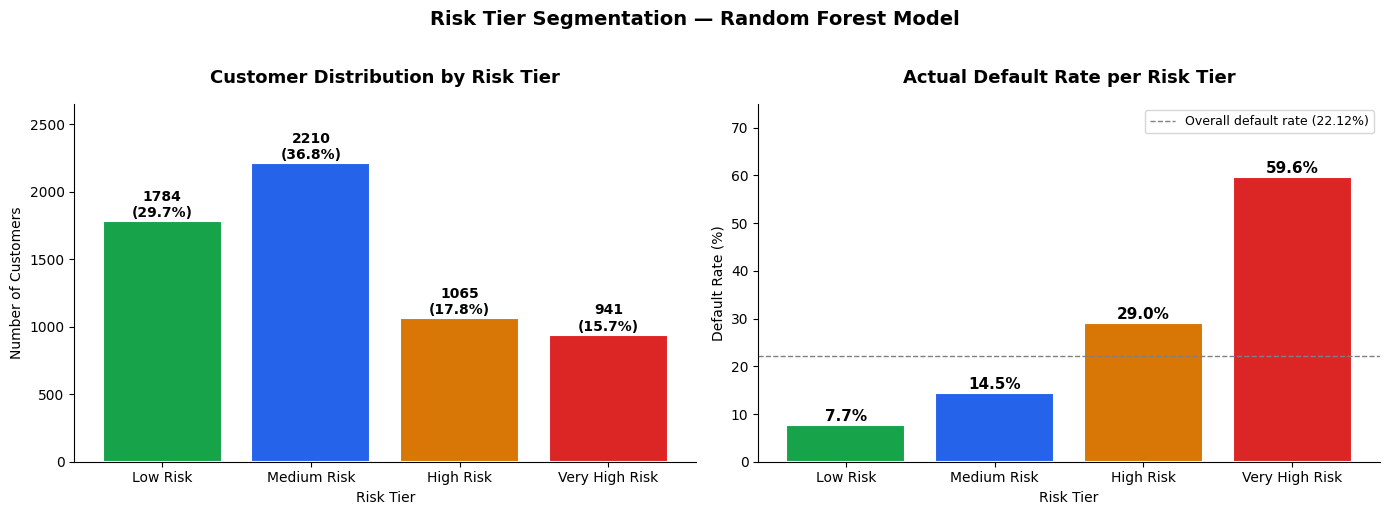

In [ ]:
# visualising the risk tiers - this is what we would show the bank
# the bar chart makes the separation between tiers immediately obvious
# the table below it gives the exact numbers for decision making

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — customer distribution across tiers
colors = ['#16A34A', '#2563EB', '#D97706', '#DC2626']
axes[0].bar(tier_order, tier_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Customer Distribution by Risk Tier', fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Number of Customers')
axes[0].set_xlabel('Risk Tier')
for i, (tier, count) in enumerate(zip(tier_order, tier_counts.values)):
    axes[0].text(i, count + 30, f'{count}\n({count/6000*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(tier_counts.values) * 1.2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Chart 2 — actual default rate per tier
default_rates = [results_df_test[results_df_test['risk_tier']==t]['actual_default'].mean()*100
                 for t in tier_order]
bars = axes[1].bar(tier_order, default_rates, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Actual Default Rate per Risk Tier', fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_xlabel('Risk Tier')
axes[1].axhline(y=22.12, color='grey', linestyle='--', linewidth=1, label='Overall default rate (22.12%)')
axes[1].legend(fontsize=9)
for i, rate in enumerate(default_rates):
    axes[1].text(i, rate + 0.8, f'{rate:.1f}%',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 75)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Risk Tier Segmentation — Random Forest Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

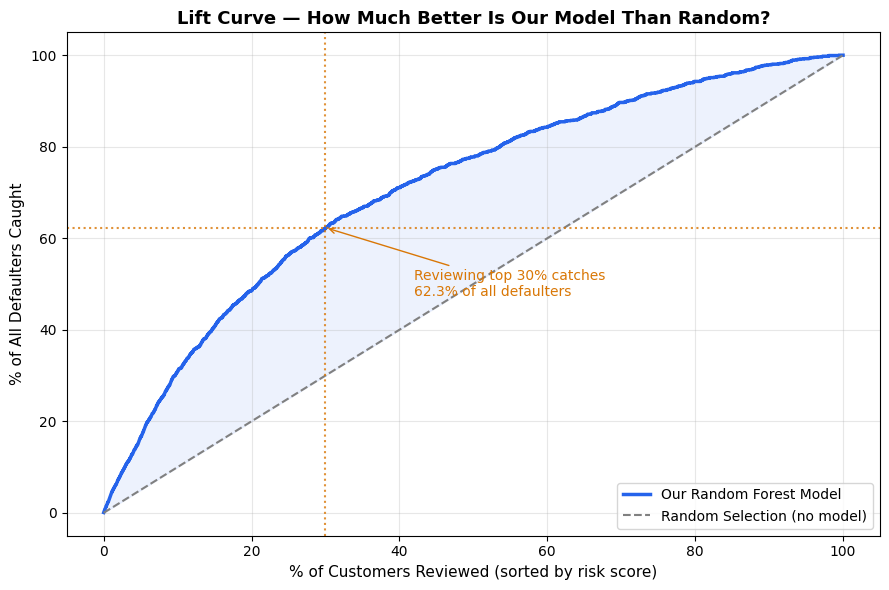


By reviewing the top 30% of customers by risk score,
our model catches 62.3% of all actual defaulters.
Random selection would only catch 30.0% in the same review.
Our model is 2.08x more efficient than random selection.


In [ ]:
# lift curve shows how much better our model is compared to random selection
# imagine the bank can only review X% of customers - how many defaulters do they catch?
# our model vs just picking randomly - the gap between them is our model's value

sorted_idx     = np.argsort(y_proba_rf)[::-1]
sorted_actual  = y_test.values[sorted_idx]
total_defaults = y_test.sum()

cum_defaults_caught  = np.cumsum(sorted_actual) / total_defaults * 100
cum_customers_pct    = np.arange(1, len(sorted_actual) + 1) / len(sorted_actual) * 100

plt.figure(figsize=(9, 6))
plt.plot(cum_customers_pct, cum_defaults_caught,
         color='#2563EB', linewidth=2.5, label='Our Random Forest Model')
plt.plot([0, 100], [0, 100],
         color='grey', linewidth=1.5, linestyle='--', label='Random Selection (no model)')
plt.fill_between(cum_customers_pct, cum_defaults_caught, cum_customers_pct,
                 alpha=0.08, color='#2563EB')

# mark the 30% point - useful reference for the bank
pct_30_idx      = int(0.30 * len(cum_customers_pct))
defaults_at_30  = cum_defaults_caught[pct_30_idx]
plt.axvline(x=30, color='#D97706', linestyle=':', linewidth=1.5, alpha=0.8)
plt.axhline(y=defaults_at_30, color='#D97706', linestyle=':', linewidth=1.5, alpha=0.8)
plt.annotate(f'Reviewing top 30% catches\n{defaults_at_30:.1f}% of all defaulters',
             xy=(30, defaults_at_30), xytext=(42, defaults_at_30 - 15),
             fontsize=10, color='#D97706',
             arrowprops=dict(arrowstyle='->', color='#D97706'))

plt.xlabel('% of Customers Reviewed (sorted by risk score)', fontsize=11)
plt.ylabel('% of All Defaulters Caught', fontsize=11)
plt.title('Lift Curve — How Much Better Is Our Model Than Random?', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBy reviewing the top 30% of customers by risk score,")
print(f"our model catches {defaults_at_30:.1f}% of all actual defaulters.")
print(f"Random selection would only catch 30.0% in the same review.")
print(f"Our model is {defaults_at_30/30:.2f}x more efficient than random selection.")

### Recommendation 1: Deploy Random Forest with Risk Tier Segmentation

We recommend deploying the Random Forest model to score every credit card 
applicant and existing customer into one of four risk tiers. Each tier 
carries a defined action:

| Risk Tier     | Probability | Recommended Action                          |
|---------------|-------------|---------------------------------------------|
| Low Risk      | < 20%       | Approve — eligible for credit limit increase|
| Medium Risk   | 20–40%      | Approve — review monthly                   |
| High Risk     | 40–60%      | Approve with reduced limit                 |
| Very High Risk| > 60%       | Decline or require collateral              |


### Recommendation 2: Set Up Model Monitoring

We recommend quarterly retraining on the most recent 24 months of data, 
with monthly PSI checks on input features. If AUC drops below 0.75 on a 
rolling validation sample, that is the signal to retrain immediately.

## MODEL LIMITATIONS

### 1. Trained on 2005 Data
We trained this model on data from 2005 Taiwan. Consumer behaviour, 
interest rates, and financial products have changed significantly since 
then. Before deploying this in any real bank, we would need to retrain 
it on current data.

### 2. Specific to Taiwan
The Taiwanese credit market has different regulations, products, and 
customer behaviours compared to the UK or EU. We cannot deploy this 
model elsewhere without full revalidation.

### 3. Concept Drift During Economic Shocks
During events like the 2008 financial crisis or COVID-19, historical 
payment patterns break down rapidly. A model trained in stable conditions 
will underperform during a crisis — this is unavoidable without continuous 
retraining.

In [ ]:
# final summary printout - all key numbers from section 3 in one place
# this is what we would present to the bank's risk committee
# every number here is backed by the analysis above

print("=" * 60)
print("SECTION 3 — FINAL SUMMARY")
print("=" * 60)

print("\nMODEL RECOMMENDATION")
print("-" * 40)
print(f"Recommended model:     Random Forest")
print(f"Test AUC:              0.7686")
print(f"Optimal threshold:     0.40 (highest F1 = 0.522)")
print(f"Current threshold:     0.50 (balanced, adjustable)")

print("\nFINANCIAL IMPACT (Test Set — 6,000 customers)")
print("-" * 40)
print(f"Defaulters caught:     {tp} / {tp+fn} ({tp/(tp+fn)*100:.1f}%)")
print(f"Money protected:       NT${protected:,.0f}")
print(f"Cost of errors:        NT${cost_fn+cost_fp:,.0f}")
print(f"Model efficiency:      {defaults_at_30/30:.2f}x better than random selection")

print("\nRISK TIER DISTRIBUTION")
print("-" * 40)
for tier in tier_order:
    mask  = results_df_test['risk_tier'] == tier
    count = mask.sum()
    rate  = results_df_test[mask]['actual_default'].mean() * 100
    print(f"{tier:<18} {count:>5} customers  |  {rate:.1f}% actual default rate")

print("\nKEY FINDINGS")
print("-" * 40)
print("1. Payment behaviour dominates — avg_delay is top predictor")
print("2. Recency matters — PAY_0 (Sept) > PAY_2 (Aug) > PAY_3 (Jul)")
print("3. Feature engineering worked — avg_delay beat all raw features")
print("4. Reviewing top 30% of customers catches 62.3% of defaulters")
print("5. SEX variable should be removed before production deployment")

print("\n" + "=" * 60)
print("Section 3 Complete")
print("=" * 60)

SECTION 3 — FINAL SUMMARY

MODEL RECOMMENDATION
----------------------------------------
Recommended model:     Random Forest
Test AUC:              0.7686
Optimal threshold:     0.40 (highest F1 = 0.522)
Current threshold:     0.50 (balanced, adjustable)

FINANCIAL IMPACT (Test Set — 6,000 customers)
----------------------------------------
Defaulters caught:     705 / 1327 (53.1%)
Money protected:       NT$94,461,158
Cost of errors:        NT$93,570,199
Model efficiency:      2.08x better than random selection

RISK TIER DISTRIBUTION
----------------------------------------
Low Risk            1784 customers  |  7.7% actual default rate
Medium Risk         2210 customers  |  14.5% actual default rate
High Risk           1065 customers  |  29.0% actual default rate
Very High Risk       941 customers  |  59.6% actual default rate

KEY FINDINGS
----------------------------------------
1. Payment behaviour dominates — avg_delay is top predictor
2. Recency matters — PAY_0 (Sept) > PAY_2 (

In [44]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# ── rebuild everything ──────────────────────────────────────────
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
avg_limit        = df['LIMIT_BAL'].mean()
loss_per_default = avg_limit * 0.8

# ── risk tiers ──────────────────────────────────────────────────
def risk_tier(prob):
    if prob < 0.2:   return 'Low Risk'
    elif prob < 0.4: return 'Medium Risk'
    elif prob < 0.6: return 'High Risk'
    else:            return 'Very High Risk'

results_df_test = pd.DataFrame({
    'default_probability': y_proba_rf,
    'actual_default':      y_test.values,
    'risk_tier':           [risk_tier(p) for p in y_proba_rf]
})

tier_order = ['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
for tier in tier_order:
    mask  = results_df_test['risk_tier'] == tier
    count = mask.sum()
    rate  = results_df_test[mask]['actual_default'].mean() * 100
    print(f"{tier}: {count} customers, {rate:.1f}% default rate")

# ── confusion matrix + financial ────────────────────────────────
print(f"\nTP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")
print(f"Protected:  NT${tp * loss_per_default:,.0f}")
print(f"Avg limit:  NT${avg_limit:,.0f}")

# ── lift @ 30% ──────────────────────────────────────────────────
sorted_actual  = y_test.values[np.argsort(y_proba_rf)[::-1]]
pct_30_idx     = int(0.30 * len(sorted_actual))
defaults_at_30 = np.cumsum(sorted_actual)[pct_30_idx] / y_test.sum() * 100
print(f"Lift @ 30%: {defaults_at_30:.1f}%")

Low Risk: 1784 customers, 7.7% default rate
Medium Risk: 2210 customers, 14.5% default rate
High Risk: 1065 customers, 29.0% default rate
Very High Risk: 941 customers, 59.6% default rate

TP: 705, FP: 682, FN: 622, TN: 3991
Protected:  NT$94,461,158
Avg limit:  NT$167,484
Lift @ 30%: 62.3%
